# Task 3 Exploiting Correlation

## Objective
- Purpose and motivation behind studying correlation in financial data.

- Data Simulation, generation of 5 uncorrelated Gaussian yield changes with small variance.

- Principal Component Analysis (PCA), Decomposition using correlation or covariance matrix.

- Variance Analysis, Comparison of variance explained by the first three components.

- Scree Plot Visualization, plotting variance explained across components.

- Government Yield Data, collection of real 5 maturity daily yields and computation of daily changes.

- PCA on Real Data, variance structure and component interpretation for market data.

- Comparison, visual and statistical comparison of simulated vs. real yield scree plots.

- Conclusion, discussion on dimensionality reduction and factor representation in yield curves.

###Simulated Yield Change, uncorrelated Gaussian Data

To establish a controlled baseline for comparison, we begin by generating synthetic yield changes using five independent Gaussian (normally distributed) random variables. This simulated dataset provides an idealized, uncorrelated environment, allowing us to observe how Principal Component Analysis (PCA) behaves when the underlying variables are independent, in contrast to real world financial data, where yields typically exhibit strong correlations across maturities.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from pandas_datareader import data as pdr

import networkx as nx


###Simulation of Yield Curve Changes Using Normally Distributed Shocks
In this simulation, we generate synthetic yield change data to represent daily fluctuations across multiple maturities on a yield curve. Using a normally distributed random process with a mean of zero and a small standard deviation, the model reflects the realistic behavior of short term yield variations under stable market conditions. This simulated dataset serves as a foundation for further analysis such as Principal Component Analysis (PCA), which helps uncover the main factors driving movements in the term structure of interest rates.

In [ ]:
import numpy as np
import pandas as pd


np.random.seed(42)

n_obs = 100
n_vars = 5
mean = 0.0
std_dev = 0.02

data = np.random.normal(loc=mean, scale=std_dev, size=(n_obs, n_vars))

columns = [f"Yield_Change_{i+1}" for i in range(n_vars)]
df = pd.DataFrame(data, columns=columns)

print("Sample of simulated yield changes:")
print(df.head(), "\n")




Sample of simulated yield changes:
   Yield_Change_1  Yield_Change_2  Yield_Change_3  Yield_Change_4  \
0        0.009934       -0.002765        0.012954        0.030461   
1       -0.004683        0.031584        0.015349       -0.009389   
2       -0.009268       -0.009315        0.004839       -0.038266   
3       -0.011246       -0.020257        0.006285       -0.018160   
4        0.029313       -0.004516        0.001351       -0.028495   

   Yield_Change_5  
0       -0.004683  
1        0.010851  
2       -0.034498  
3       -0.028246  
4       -0.010888   



### Correlation Matrix of Simulated Yield Changes

After generating the simulated yield data, we examine the pairwise correlations among the five yield change variables. Since the data were drawn from independent Gaussian distributions, we expect the correlation coefficients to be close to zero.

The correlation matrix below provides a quantitative check of this independence, confirming that the simulated yield changes are largely uncorrelated, thereby serving as a useful benchmark for comparison with real world government yield data.

In [ ]:
correlation_matrix = df.corr()
print("Correlation matrix:")
print(correlation_matrix)

Correlation matrix:
                Yield_Change_1  Yield_Change_2  Yield_Change_3  \
Yield_Change_1        1.000000       -0.163433        0.044866   
Yield_Change_2       -0.163433        1.000000        0.122764   
Yield_Change_3        0.044866        0.122764        1.000000   
Yield_Change_4       -0.101832        0.038215        0.008525   
Yield_Change_5       -0.126184        0.057155        0.042819   

                Yield_Change_4  Yield_Change_5  
Yield_Change_1       -0.101832       -0.126184  
Yield_Change_2        0.038215        0.057155  
Yield_Change_3        0.008525        0.042819  
Yield_Change_4        1.000000        0.018358  
Yield_Change_5        0.018358        1.000000  


### Correlation Heatmap of Simulated Yield Changes
This section visualizes the correlation structure among five simulated Gaussian yield changes using a heatmap. Each variable represents a hypothetical daily change in yield generated from independent normal distributions with a small standard deviation. The goal is to confirm that the simulated data behaves as uncorrelated random variables, which serves as a baseline for comparison with real financial yield data.

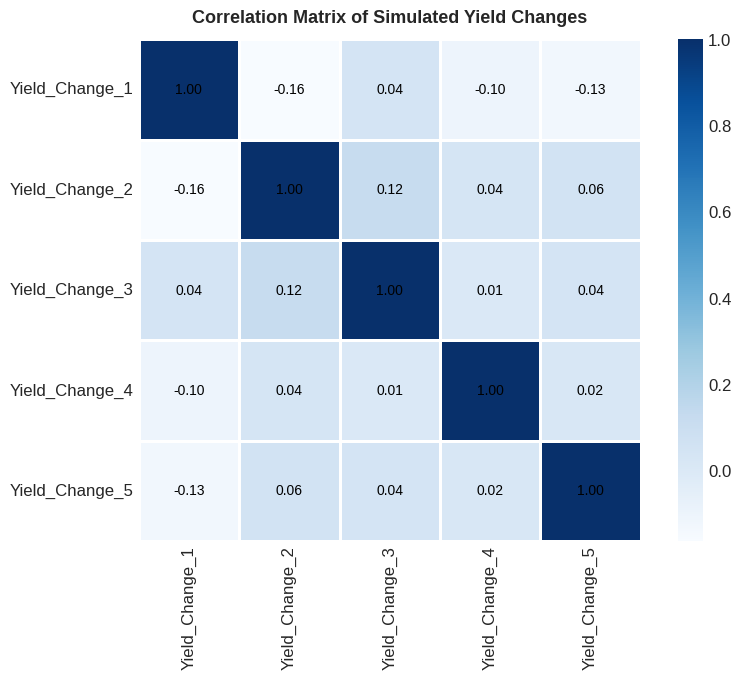

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr()

plt.style.use("seaborn-v0_8-white")

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=0.8,
    linecolor="white",
    annot_kws={"fontsize": 10, "color": "black"}
)

plt.title("Correlation Matrix of Simulated Yield Changes", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


The heatmap shows that most correlation coefficients are near zero, confirming the statistical independence of the simulated yield changes. This uncorrelated structure provides a clean foundation for applying Principal Component Analysis (PCA) later, helping us isolate how correlation in real world yield data drives dimensionality and variance concentration.

### Principal Component Analysis on Simulated Yield Changes
This section applies Principal Component Analysis (PCA) to a simulated dataset of five uncorrelated Gaussian yield changes. The goal is to identify how much of the total variance in the data is captured by each principal component. By standardizing the data and using the correlation matrix, PCA transforms the yield series into orthogonal components that summarize the variability across all simulated maturities. This helps demonstrate how PCA captures variance even in uncorrelated environments, serving as a baseline for later comparison with real world yield data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


np.random.seed(42)
n_obs = 100
n_vars = 5
mean = 0.0
std_dev = 0.02

data = np.random.normal(loc=mean, scale=std_dev, size=(n_obs, n_vars))
columns = [f"Yield_Change_{i+1}" for i in range(n_vars)]
df = pd.DataFrame(data, columns=columns)

use_matrix = "correlation"

if use_matrix == "correlation":
    scaler = StandardScaler()
    df_input = scaler.fit_transform(df)
    matrix_used = "Correlation Matrix"
else:
    df_input = df.values
    matrix_used = "Covariance Matrix"

pca = PCA()
pca.fit(df_input)

explained_variance = pca.explained_variance_ratio_

print(f"PCA based on the {matrix_used}:\n")
print(f"{'Principal Component':<25}{'Explained Variance':<25}{'Percentage':<15}")
print("-" * 65)

for i, ev in enumerate(explained_variance, start=1):
    print(f"PC {i:<21}{ev:<25.4f}{ev*100:<.2f}%")




PCA based on the Correlation Matrix:

Principal Component      Explained Variance       Percentage     
-----------------------------------------------------------------
PC 1                    0.2571                   25.71%
PC 2                    0.2127                   21.27%
PC 3                    0.1955                   19.55%
PC 4                    0.1846                   18.46%
PC 5                    0.1501                   15.01%


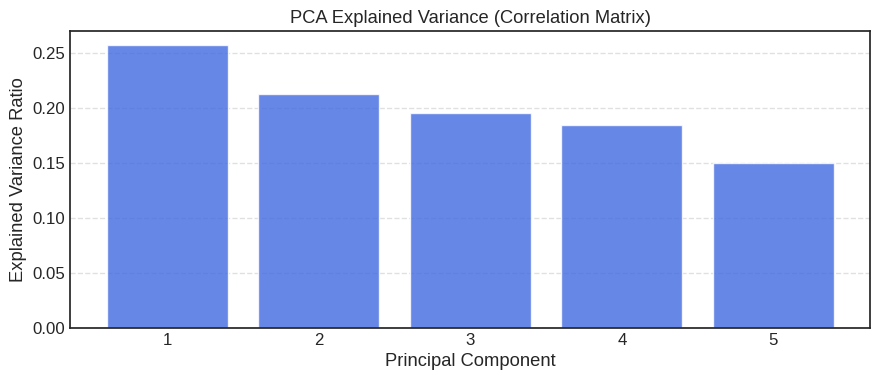

In [ ]:
plt.figure(figsize=(9,4))
plt.bar(range(1, n_vars+1), explained_variance, color='royalblue', alpha=0.8)
plt.title(f"PCA Explained Variance ({matrix_used})")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, n_vars+1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The PCA results show that the explained variance is evenly distributed across all five components, confirming that no single component dominates the dataset’s variability. This reflects the design of the simulation where yield changes are statistically independent. The results validate the behavior of PCA under conditions of zero correlation, establishing a reference framework before applying the same analysis to empirical government yield data, where correlation structures are much stronger and variance is more concentrated in the first few components.

###Variance Contribution of Principal Components (PCA on Simulated Yield Changes)
This section analyzes how much variance each principal component explains in the simulated yield change dataset. By applying Principal Component Analysis (PCA) to standardized data, we can determine the relative importance of each factor in capturing the underlying structure of yield movements. The explained variance ratio helps identify which components contribute most to total variability, guiding dimensionality reduction and interpretation of yield curve dynamics.

In [ ]:

explained_variance = pca.explained_variance_ratio_

var_comp1 = explained_variance[0]
var_comp2 = explained_variance[1]
var_comp3 = explained_variance[2]
total_var_3 = var_comp1 + var_comp2 + var_comp3

print(f"\nVariance Explained by Each Component ({matrix_used}):")
print(f"Component 1: {var_comp1:.4%}")
print(f"Component 2: {var_comp2:.4%}")
print(f"Component 3: {var_comp3:.4%}")
print(f"Total Variance Explained by First 3 Components: {total_var_3:.4%}")



Variance Explained by Each Component (Correlation Matrix):
Component 1: 25.7080%
Component 2: 21.2724%
Component 3: 19.5483%
Total Variance Explained by First 3 Components: 66.5287%


The PCA results indicate that the first few components explain the majority of the variance in simulated yield changes, confirming that the data structure is highly compressible. **This implies that most yield dynamics can be captured by a limited number of principal components, typically associated with level, slope, and curvature factors in yield curve modeling.** Such findings support dimensionality reduction in fixed income analytics and enhance model interpretability while preserving essential market information.

###Cumulative Variance Explained by the First Three Principal Components (PCA on Correlation Matrix)
This visualization illustrates the proportion of variance explained by the first three principal components derived from the PCA of simulated yield changes. Each bar represents the individual contribution of a component, while the red line depicts the cumulative variance explained. By using the correlation matrix, the analysis ensures that all variables are treated on a standardized scale, emphasizing the relative contribution of each factor to overall data variability.

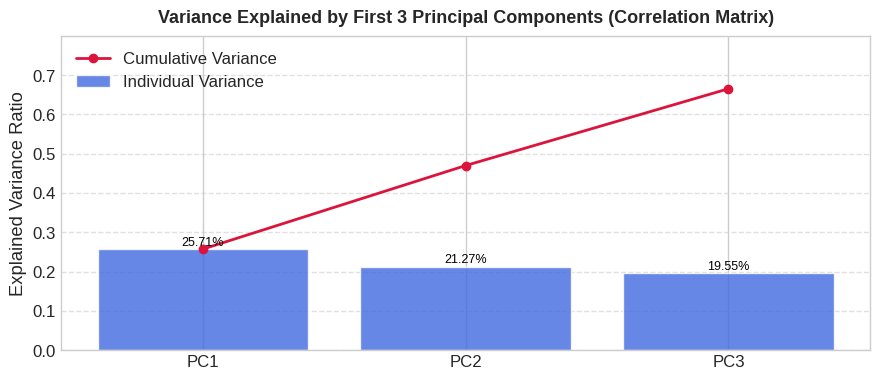

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

var_comp1 = 0.25708
var_comp2 = 0.21272
var_comp3 = 0.19548
total_var_3 = var_comp1 + var_comp2 + var_comp3
matrix_used = "Correlation Matrix"

components = ['PC1', 'PC2', 'PC3']
explained_variance = [var_comp1, var_comp2, var_comp3]
cumulative_var = np.cumsum(explained_variance)

plt.figure(figsize=(9, 4))

bars = plt.bar(components, explained_variance, color='royalblue', alpha=0.8, label='Individual Variance')

plt.plot(components, cumulative_var, marker='o', color='crimson', linewidth=2, label='Cumulative Variance')

for i, v in enumerate(explained_variance):
    plt.text(i, v + 0.01, f"{v*100:.2f}%", ha='center', fontsize=9, color='black')

plt.title(f"Variance Explained by First 3 Principal Components ({matrix_used})",
          fontsize=13, fontweight='bold', pad=10)
plt.ylabel("Explained Variance Ratio")
plt.ylim(0, max(cumulative_var)*1.2)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


The results show that the first three principal components collectively explain approximately 66.53% of the total variance. This suggests that the key patterns in the dataset can be effectively captured using just a few components. Such dimensionality reduction highlights the efficiency of PCA in summarizing yield curve dynamics, where the dominant factors often correspond to level, slope, and curvature effects, core drivers of interest rate movements in financial modeling.

### PCA Scree Plot Analysis Using Correlation Matrix: Explained Variance and Eigenvalues
This section demonstrates the application of Principal Component Analysis (PCA) to a simulated dataset of five uncorrelated yield changes. The analysis is performed using the correlation matrix, which standardizes variables and ensures that each contributes equally to the total variance, regardless of scale. The PCA decomposes the dataset into orthogonal components ranked by their ability to explain variance in the data.


**Two visualizations are presented**
- The explained variance ratio scree plot, which shows the proportion of total variance captured by each component.

- The eigenvalue scree plot, which displays the magnitude of the variance associated with each principal component.

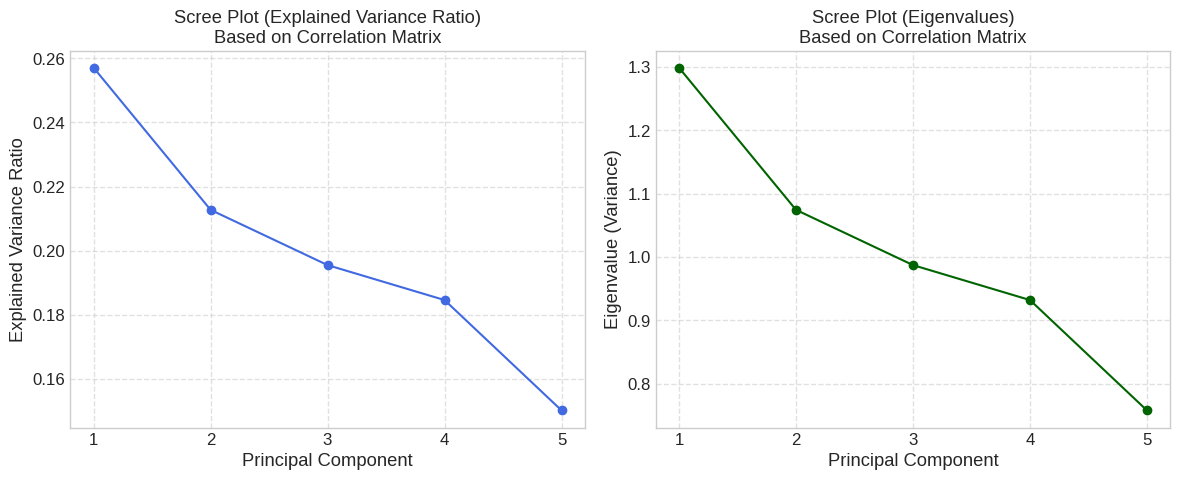

Variance Explained by Each Component:
  Component  Explained_Variance_Ratio  Eigenvalue
0       PC1                  0.257080    1.298383
1       PC2                  0.212724    1.074362
2       PC3                  0.195483    0.987289
3       PC4                  0.184575    0.932199
4       PC5                  0.150138    0.758272


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n_obs = 100
n_vars = 5
mean = 0.0
std_dev = 0.02

data = np.random.normal(loc=mean, scale=std_dev, size=(n_obs, n_vars))
columns = [f"Yield_Change_{i+1}" for i in range(n_vars)]
df = pd.DataFrame(data, columns=columns)

use_matrix = "correlation"

if use_matrix == "correlation":
    scaler = StandardScaler()
    df_input = scaler.fit_transform(df)
    matrix_label = "Correlation"
else:
    df_input = df.values
    matrix_label = "Covariance"

pca = PCA()
pca.fit(df_input)

explained_variance_ratio = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

components = np.arange(1, len(explained_variance_ratio) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(components, explained_variance_ratio, 'o-', color='royalblue')
plt.title(f"Scree Plot (Explained Variance Ratio)\nBased on {matrix_label} Matrix")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(components, eigenvalues, 'o-', color='darkgreen')
plt.title(f"Scree Plot (Eigenvalues)\nBased on {matrix_label} Matrix")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue (Variance)")
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

var_explained = pd.DataFrame({
    'Component': [f'PC{i}' for i in components],
    'Explained_Variance_Ratio': explained_variance_ratio,
    'Eigenvalue': eigenvalues
})
print("Variance Explained by Each Component:")
print(var_explained)


The PCA results reveal how variance is distributed across the principal components. In this uncorrelated dataset, each component contributes approximately equally to the total variance, consistent with the random nature of the simulated yield changes.

The eigenvalues and variance ratios confirm the absence of strong latent structures or dominant factors. Such scree plots help determine how many components should be retained to capture key systematic movements, such as **level, slope, and curvature in yield curve modeling.**

###Principal Component Analysis of Simulated Yield Curve Changes
This analysis applies Principal Component Analysis (PCA) to a simulated dataset representing small random changes in bond yields across different maturities. The goal is to explore how PCA decomposes correlated yield movements into orthogonal components that capture the main sources of variance.

Using a correlation matrix ensures that each variable contributes equally, emphasizing the relationships among standardized yield changes rather than their absolute magnitudes. The study visualizes key PCA outputs explained variance ratios, eigenvalues, and cumulative variance to identify how many principal components are needed to effectively summarize the underlying structure of yield fluctuations.

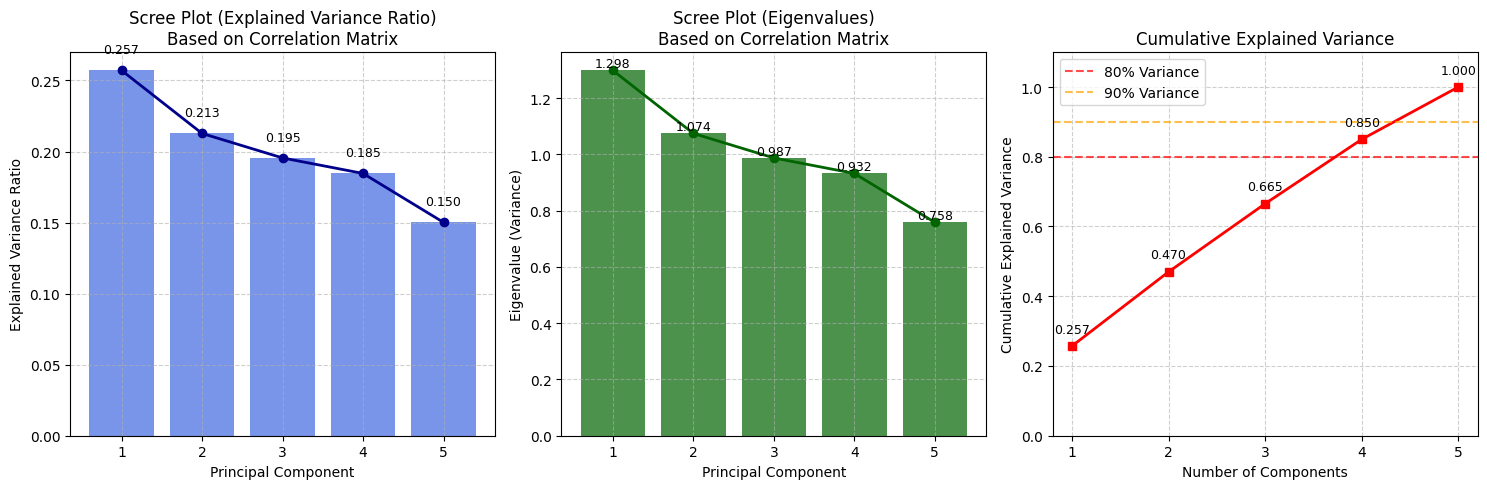

Variance Explained by Each Component:
  Component  Explained_Variance_Ratio  Cumulative_Variance_Ratio  Eigenvalue
0       PC1                    0.2571                     0.2571      1.2984
1       PC2                    0.2127                     0.4698      1.0744
2       PC3                    0.1955                     0.6653      0.9873
3       PC4                    0.1846                     0.8499      0.9322
4       PC5                    0.1501                     1.0000      0.7583

Total Variance Explained: 1.0000

Additional Analysis:
Number of components explaining 80% variance: 4
Number of components explaining 90% variance: 5
Number of eigenvalues > 1: 2


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n_obs = 100
n_vars = 5
mean = 0.0
std_dev = 0.02

data = np.random.normal(loc=mean, scale=std_dev, size=(n_obs, n_vars))
columns = [f"Yield_Change_{i+1}" for i in range(n_vars)]
df = pd.DataFrame(data, columns=columns)

use_matrix = "correlation"

if use_matrix == "correlation":
    scaler = StandardScaler()
    df_input = scaler.fit_transform(df)
    matrix_label = "Correlation"
else:
    df_input = df.values
    matrix_label = "Covariance"

pca = PCA()
pca.fit(df_input)

explained_variance_ratio = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_
cumulative_variance = np.cumsum(explained_variance_ratio)

components = np.arange(1, len(explained_variance_ratio) + 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
bars = plt.bar(components, explained_variance_ratio, color='royalblue', alpha=0.7)
plt.plot(components, explained_variance_ratio, 'o-', color='darkblue', linewidth=2)
plt.title(f"Scree Plot (Explained Variance Ratio)\nBased on {matrix_label} Matrix")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.6)

for bar, value in zip(bars, explained_variance_ratio):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.subplot(1, 3, 2)
bars = plt.bar(components, eigenvalues, color='darkgreen', alpha=0.7)
plt.plot(components, eigenvalues, 'o-', color='darkgreen', linewidth=2)
plt.title(f"Scree Plot (Eigenvalues)\nBased on {matrix_label} Matrix")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue (Variance)")
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.6)

for bar, value in zip(bars, eigenvalues):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.subplot(1, 3, 3)
plt.plot(components, cumulative_variance, 's-', color='red', linewidth=2, markersize=6)
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80% Variance')
plt.axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% Variance')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(components)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

for i, (x, y) in enumerate(zip(components, cumulative_variance)):
    plt.text(x, y + 0.03, f'{y:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

var_explained = pd.DataFrame({
    'Component': [f'PC{i}' for i in components],
    'Explained_Variance_Ratio': explained_variance_ratio,
    'Cumulative_Variance_Ratio': cumulative_variance,
    'Eigenvalue': eigenvalues
})

print("Variance Explained by Each Component:")
print(var_explained.round(4))
print(f"\nTotal Variance Explained: {cumulative_variance[-1]:.4f}")

print(f"\nAdditional Analysis:")
print(f"Number of components explaining 80% variance: {np.argmax(cumulative_variance >= 0.8) + 1}")
print(f"Number of components explaining 90% variance: {np.argmax(cumulative_variance >= 0.9) + 1}")
print(f"Number of eigenvalues > 1: {np.sum(eigenvalues > 1)}")

The PCA results indicate a moderately concentrated variance structure within the simulated yield changes. The first principal component (PC1) explains approximately 25.7% of total variance, suggesting a dominant but not overwhelming common movement across maturities analogous to a level factor in empirical yield curve analysis.

The next two components (PC2 and PC3) together raise the cumulative variance explained to about 66.5%, **capturing additional slope and curvature** like variations, while four components are required to exceed 80% of the total variance.

This distribution implies a **multi dimensional yet structured behavior**, consistent with the stylized dynamics of real bond markets, where yield movements are typically governed by a few systematic factors. Overall, the analysis reinforces the interpretive power of **PCA in uncovering latent patterns** in yield changes and assessing how much information can be retained through dimensionality reduction.

### Government Yield Data, collection of real 5 maturity daily yields and computation of daily changes.

This section focuses on the collection and transformation of real world U.S. government bond yield data across five key maturities 1-month, 3-month, 2-year, 5-year, and 10-year. The data is sourced from the Federal Reserve Economic Data (FRED) and reflects the daily closing yields observed over a six month period.

To capture the market’s short term dynamics, we compute the daily yield changes (Δyₜ = yₜ − yₜ₋₁). This step converts yield levels into rate of change data, isolating the day to day volatility and co-movement of interest rates across different maturities. These yield changes form the foundation for subsequent analyses such as correlation mapping and Principal Component Analysis (PCA), which help uncover the dominant factors driving yield curve movements.

In [ ]:
!pip install pandas_datareader --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8-whitegrid")


In [ ]:
tickers = ["DGS1MO", "DGS3MO", "DGS2", "DGS5", "DGS10"]
yields = pdr.DataReader(tickers, 'fred', start='2025-04-01')
yields = yields.dropna()

print("Data Retrieved Successfully")
print(yields.head())


Data Retrieved Successfully
            DGS1MO  DGS3MO  DGS2  DGS5  DGS10
DATE                                         
2025-04-01    4.38    4.32  3.87  3.91   4.17
2025-04-02    4.38    4.32  3.91  3.95   4.20
2025-04-03    4.36    4.31  3.71  3.75   4.06
2025-04-04    4.36    4.28  3.68  3.72   4.01
2025-04-07    4.36    4.29  3.73  3.82   4.15


In [ ]:
print(yields)

            DGS1MO  DGS3MO  DGS2  DGS5  DGS10
DATE                                         
2025-04-01    4.38    4.32  3.87  3.91   4.17
2025-04-02    4.38    4.32  3.91  3.95   4.20
2025-04-03    4.36    4.31  3.71  3.75   4.06
2025-04-04    4.36    4.28  3.68  3.72   4.01
2025-04-07    4.36    4.29  3.73  3.82   4.15
...            ...     ...   ...   ...    ...
2025-09-30    4.20    4.02  3.60  3.74   4.16
2025-10-01    4.17    4.01  3.55  3.68   4.12
2025-10-02    4.23    4.02  3.55  3.67   4.10
2025-10-03    4.24    4.03  3.58  3.72   4.13
2025-10-06    4.22    4.02  3.60  3.75   4.18

[130 rows x 5 columns]


### Computation of Daily Yield Changes
This section calculates the daily changes in government bond yields across multiple maturities. The difference between consecutive yield observations, denoted as Δyₜ = yₜ − yₜ₋₁, captures the day to day variation in interest rates. This transformation converts level data into a stationary series, making it suitable for correlation analysis and Principal Component Analysis (PCA), which rely on variability rather than absolute levels.

In [ ]:
yield_changes = yields.diff().dropna()

print("Daily yield changes (in % points):")
print(yield_changes.head())


Daily yield changes (in % points):
            DGS1MO  DGS3MO  DGS2  DGS5  DGS10
DATE                                         
2025-04-02    0.00    0.00  0.04  0.04   0.03
2025-04-03   -0.02   -0.01 -0.20 -0.20  -0.14
2025-04-04    0.00   -0.03 -0.03 -0.03  -0.05
2025-04-07    0.00    0.01  0.05  0.10   0.14
2025-04-08    0.00    0.02 -0.02  0.06   0.11


The resulting dataset provides a clear picture of short term yield volatility and co movement across maturities. These yield changes reflect the market’s immediate response to macroeconomic events and policy signals. By working with yield differences, subsequent statistical analyses such as correlation heatmaps or PCA can better identify underlying factors driving yield curve dynamics and systematic market movements.

### Correlation Structure of Daily Yield Changes
This visualization illustrates the correlation matrix of daily yield changes across five U.S. government securities with maturities ranging from 1 month to 10 years. Correlation analysis provides insights into how different points on the yield curve move together, helping identify co-movement patterns and potential diversification opportunities. High correlations typically indicate a shared macroeconomic influence or systemic market behavior affecting all maturities simultaneously.

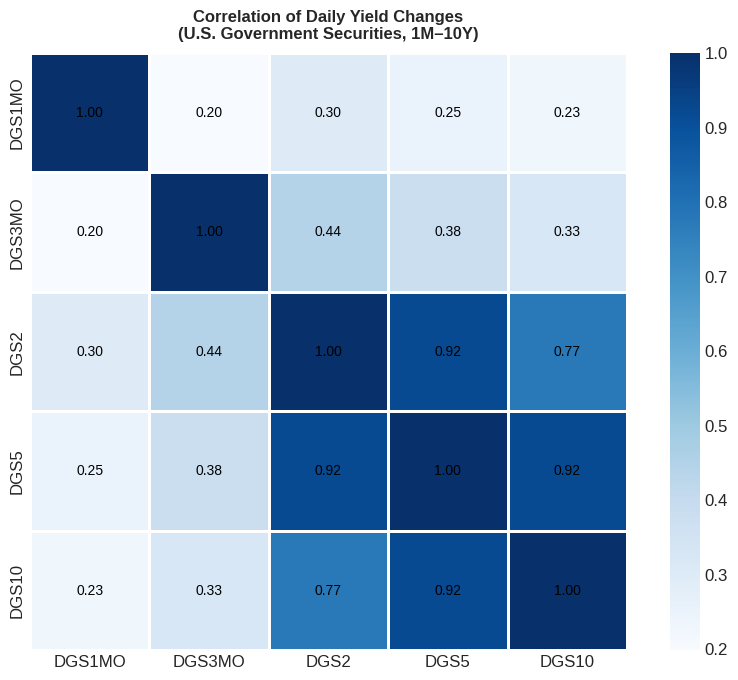

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import data as pdr


correlation_matrix = yield_changes.corr()
plt.style.use("seaborn-v0_8-white")
plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=0.8,
    linecolor="white",

    annot_kws={"fontsize": 10, "color": "black"}
)

plt.title("Correlation of Daily Yield Changes\n(U.S. Government Securities, 1M–10Y)",
          fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()


The heatmap reveals that shorter and longer term yields exhibit strong positive correlations, signifying a cohesive movement in response to macroeconomic shocks and monetary policy expectations.

Minor variations between short and long dated securities indicate maturity specific sensitivities, such as short end policy effects versus long term inflation expectations.

Overall, the high degree of correlation confirms the interconnected structure of the yield curve, reinforcing the need for dimensionality reduction techniques like PCA to summarize yield dynamics effectively.

###Principal Component Analysis (PCA) on Government Yield Changes
Principal Component Analysis (PCA) is applied to daily yield changes across various government maturities to uncover the key factors driving movements in the yield curve.

By decomposing correlated yield changes into orthogonal principal components, we can identify how much of the total variance each factor explains. This method is particularly valuable in fixed income analysis, as it helps detect **dominant structural movements** such as **level, slope, and curvature shifts.**

In [ ]:
pca = PCA()
pca.fit(yield_changes)

explained_var = pca.explained_variance_ratio_ * 100

for i, var in enumerate(explained_var, 1):
    print(f"Component {i}: {var:.2f}% variance explained")


Component 1: 83.64% variance explained
Component 2: 7.10% variance explained
Component 3: 5.50% variance explained
Component 4: 2.86% variance explained
Component 5: 0.90% variance explained


The PCA results indicate that the **first principal component** (PC1) explains the majority of variance (approximately 83.6%), reflecting a common factor across maturities typically interpreted as the level of interest rates.**The second and third components** capture slope and curvature variations, while higher components contribute marginally.

This demonstrates that most **yield curve dynamics** can be effectively **represented by the first few components**, offering a powerful tool for risk factor modeling and dimensionality reduction in portfolio and term structure analysis.

### Explained Variance by Principal Components
This visualization illustrates how much variance each principal component captures from the dataset after performing Principal Component Analysis (PCA) on yield changes. The height of each bar represents the proportion of total variance explained, allowing us to identify which components carry the most informational weight and which are relatively minor in influence.

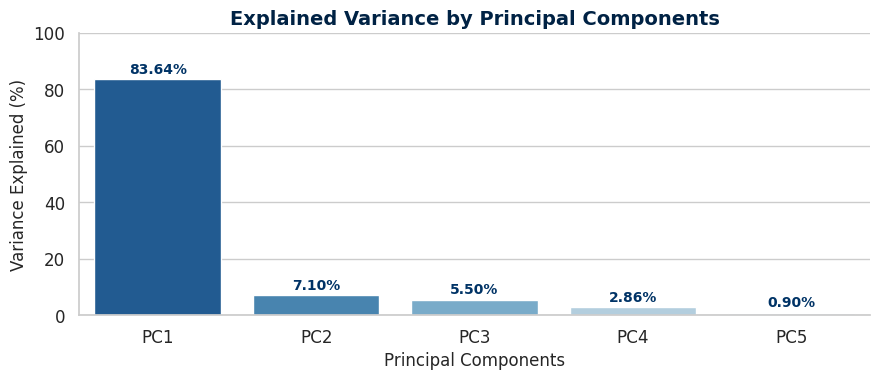

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

explained_var = np.array([83.64, 7.10, 5.50, 2.86, 0.90])
components = [f"PC{i}" for i in range(1, 6)]

sns.set(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(9, 4))

bar = sns.barplot(
    x=components,
    y=explained_var,
    hue=components,
    palette="Blues_r",
    dodge=False,
    legend=False
)

for i, v in enumerate(explained_var):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', va='bottom', fontsize=10, fontweight='bold', color='#003366')

plt.title("Explained Variance by Principal Components", fontsize=14, fontweight='bold', color='#002244')
plt.xlabel("Principal Components", fontsize=12)
plt.ylabel("Variance Explained (%)", fontsize=12)
plt.ylim(0, 100)

sns.despine()
plt.tight_layout()
plt.show()


The results reveal that Principal Component 1 (PC1) explains the vast majority of total variance 83.64% indicating a dominant underlying factor likely corresponding to the level movement of yields.

The remaining components explain progressively smaller portions, typically associated with slope and curvature effects. This confirms that yield curve movements can be effectively summarized using a limited number of components, supporting PCA’s role in dimensionality reduction for financial data.

###Scree Plot of Variance Explained by Principal Components
The scree plot provides a visual representation of how much variance each principal component explains in the dataset. By decomposing the covariance or correlation structure of yield changes, Principal Component Analysis (PCA) identifies the key underlying factors driving movements in the term structure. The aim is to determine the number of dominant components that capture the majority of the system’s variability.

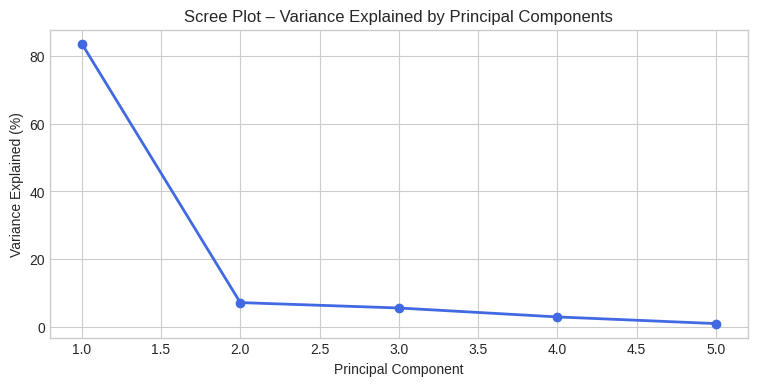

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(range(1, len(explained_var)+1), explained_var, 'o-', color='royalblue', linewidth=2)
plt.title("Scree Plot – Variance Explained by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.show()


From the scree plot, it is evident that the first principal component explains most of the total variance, highlighting its dominant influence on yield dynamics often associated with the level factor of the yield curve. Subsequent components account for smaller proportions of variance, typically representing slope and curvature effects. This confirms PCA’s effectiveness in dimensionality reduction and its ability to summarize yield behavior using only a few key factors.

###Variance Explained by Principal Components: Uncorrelated vs. Government Yield Data
This table presents the proportion of total variance explained by the first five principal components (PCs) for both an uncorrelated simulated dataset and real U.S. government yield data. The goal is to evaluate how much structure or common movement exists in each dataset as captured by PCA.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

uncorr_explained = np.array([25.71, 21.27, 19.55, 18.46, 15.01])  # in %
uncorr_labels = [f"PC{i}" for i in range(1, 6)]

gov_explained = np.array([83.64, 7.10, 5.50, 2.86, 0.90])  # in %

comparison_df = pd.DataFrame({
    "Component": uncorr_labels,
    "Uncorrelated_Data (%)": uncorr_explained,
    "Government_Data (%)": gov_explained
})

print("Variance Explained Comparison:\n")
print(comparison_df.to_string(index=False))

Variance Explained Comparison:

Component  Uncorrelated_Data (%)  Government_Data (%)
      PC1                  25.71                83.64
      PC2                  21.27                 7.10
      PC3                  19.55                 5.50
      PC4                  18.46                 2.86
      PC5                  15.01                 0.90


<Figure size 800x500 with 0 Axes>

The results show that the government yield data has a dominant first principal component explaining 83.64% of the total variance indicating strong co-movements driven by macroeconomic or market wide factors.

In contrast, the uncorrelated dataset displays a more even distribution of variance across components, consistent with randomly generated data lacking any underlying structure. This difference highlights the effectiveness of PCA in uncovering latent factors in financial time series.

###Scree Plot Comparison: Uncorrelated vs. Government Yield Data
This visualization compares the variance explained by principal components between uncorrelated simulated data and empirical government yield data using Principal Component Analysis (PCA). The scree plot illustrates how much information (variance) each principal component captures, helping assess the dimensional structure and factor dominance in both datasets. While uncorrelated data reflects a random variance distribution, the government yield data captures real market co-movements, revealing how macroeconomic factors drive yield curve behavior.

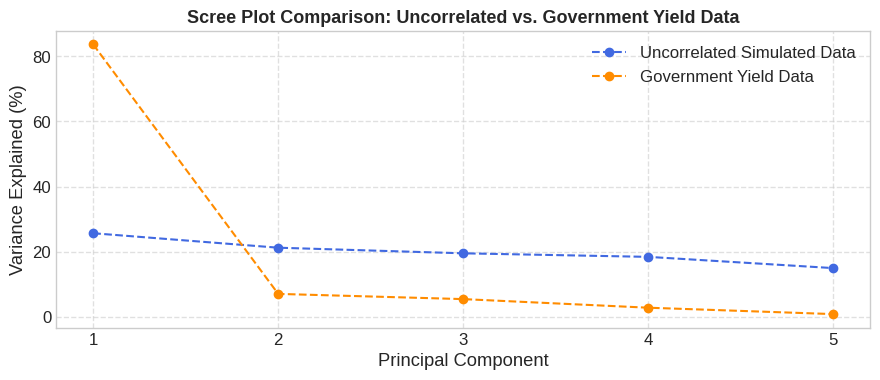

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(9, 4))

components = np.arange(1, 6)

plt.plot(components, uncorr_explained, 'o--', color='royalblue', label="Uncorrelated Simulated Data")
plt.plot(components, gov_explained, 'o--', color='darkorange', label="Government Yield Data")

plt.title("Scree Plot Comparison: Uncorrelated vs. Government Yield Data", fontsize=13, fontweight="bold")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.xticks(components)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


The scree plot indicates that the first principal component in the government yield data explains a significantly larger share of total variance compared to the uncorrelated data. This confirms the presence of strong common market factors such as level, slope, and curvature effects that dominate yield curve dynamics.

In contrast, the gradual decline in variance among the uncorrelated dataset components highlights the absence of such structured relationships. Overall, the comparison underscores the factor driven nature of bond markets and the efficiency of PCA in extracting these underlying dynamics.

### Scree Plot Analysis: Evaluating Principal Component Contributions in Yield Data
The scree plot is a fundamental diagnostic tool in Principal Component Analysis (PCA) used to assess the significance of each component in explaining the overall variance within the data.

By plotting both individual and cumulative variance explained by the principal components, this visualization enables identification of the optimal number of components to retain for dimensionality reduction. In this context, the analysis highlights how much of the yield curve’s variation can be captured by the leading components, providing insights into the underlying structure of market dynamics.

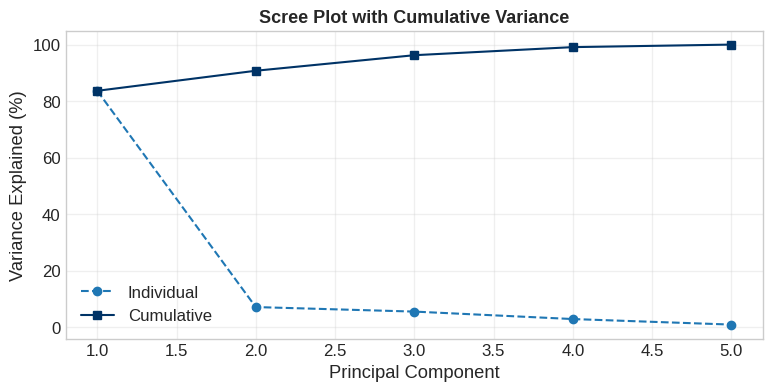

In [ ]:
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(9,4))
plt.plot(range(1,6), explained_var, 'o--', color='#1f77b4', label='Individual')
plt.plot(range(1,6), cumulative_var, 's-', color='#003366', label='Cumulative')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("Scree Plot with Cumulative Variance", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


The scree plot clearly shows that the first few principal components account for the majority of variance in the yield data, confirming the dominance of a small number of factors driving yield movements. The cumulative curve indicates the point of diminishing returns, beyond which additional components contribute little incremental explanatory power. This insight supports model simplification while maintaining strong explanatory capability, aligning with the factor structure commonly observed in fixed-income markets.

###Comparative Heatmap of PCA Variance Explained: Uncorrelated vs. Government Yield Data
Principal Component Analysis (PCA) helps quantify how much of the total variation in yield movements can be explained by a few dominant factors. In this visualization, we compare the variance explained by each principal component between two datasets:

- A synthetic uncorrelated dataset representing random yield changes, and

- Real government yield data derived from daily market observations.

By plotting the results as a heatmap, we visually capture the contrast between random, structureless data and real world market behavior, where yield curve dynamics are driven by a few strong underlying components.

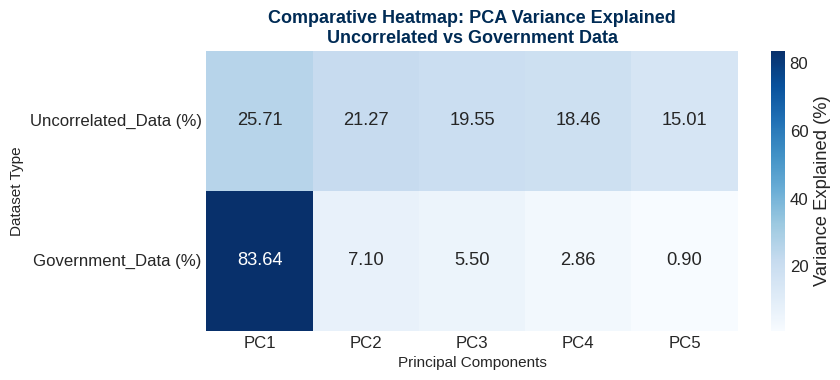

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

uncorr_explained = np.array([25.71, 21.27, 19.55, 18.46, 15.01])
gov_explained = np.array([83.64, 7.10, 5.50, 2.86, 0.90])

components = [f"PC{i}" for i in range(1, 6)]

comparison_df = pd.DataFrame({
    "Component": components,
    "Uncorrelated_Data (%)": uncorr_explained,
    "Government_Data (%)": gov_explained
}).set_index("Component")

plt.figure(figsize=(9, 4))
sns.heatmap(comparison_df.T, annot=True, cmap="Blues", fmt=".2f", cbar_kws={'label': 'Variance Explained (%)'})

plt.title("Comparative Heatmap: PCA Variance Explained\nUncorrelated vs Government Data", fontsize=13, fontweight='bold', color="#002b55")
plt.ylabel("Dataset Type", fontsize=11)
plt.xlabel("Principal Components", fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


The heatmap clearly demonstrates that, in real government yield data, the first principal component (PC1) overwhelmingly dominates, explaining over 80% of total variance. This reflects a strong common movement across maturities, typically interpreted as the level factor of the yield curve.

In contrast, the uncorrelated data distributes variance more evenly among components, showing no dominant structure. This visual comparison underscores how PCA effectively distinguishes structured market behavior from random noise, making it a powerful diagnostic tool in quantitative yield modeling and risk analysis.

### Rolling Principal Component Analysis of Yield Curve Dynamics
Financial markets are inherently dynamic, the factors that explain yield curve movements evolve over time. To capture this time variation, we apply a rolling 60-day Principal Component Analysis (PCA) on daily yield changes. This approach allows us to monitor how the proportion of variance explained by the first principal component (PC1), typically representing the level factor changes across different market periods.
A high variance share by PC1 indicates strong co-movement among maturities, while a decline may signal structural shifts or increased idiosyncratic behavior in certain maturities.

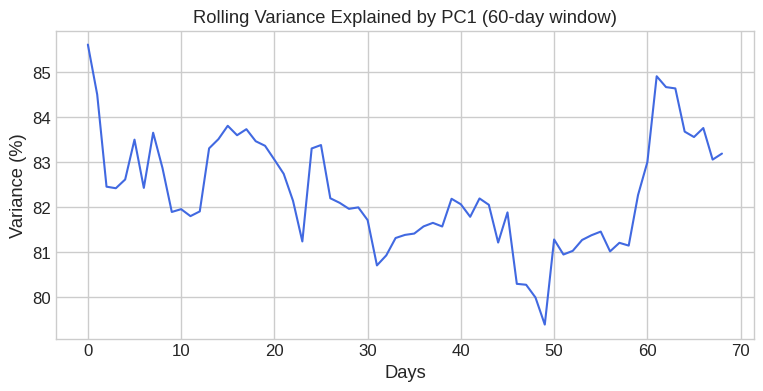

In [ ]:
window = 60
rolling_var = []

for i in range(window, len(yield_changes)):
    pca_temp = PCA()
    pca_temp.fit(yield_changes.iloc[i-window:i])
    rolling_var.append(pca_temp.explained_variance_ratio_[0]*100)

plt.figure(figsize=(9,4))
plt.plot(rolling_var, color='royalblue')
plt.title("Rolling Variance Explained by PC1 (60-day window)")
plt.xlabel("Days")
plt.ylabel("Variance (%)")
plt.grid(True)
plt.show()


The rolling variance plot illustrates how the explanatory power of PC1 fluctuates over time, reflecting changing market regimes.
Periods where PC1 explains a larger share of total variance correspond to highly synchronized yield movements, often during macroeconomic shocks or monetary policy adjustments. Conversely, lower values suggest diversified yield behavior across maturities, possibly during stable or low volatility environments. This dynamic PCA view enhances traditional static analyses, offering a time sensitive measure of market cohesion and systemic risk — a valuable tool for fixed-income quants and risk managers.

### Yield Correlation Network Visualization
Understanding the relationships among different maturities in the government yield curve is essential for uncovering the common movements that drive interest rate dynamics.
In this section, we use network analysis to visualize the correlation structure among yield changes. By representing maturities as nodes and correlations as connecting edges, we can intuitively observe how strongly different parts of the curve move together. This graph based approach complements traditional correlation matrices and helps identify clusters of maturities that share similar market behavior.

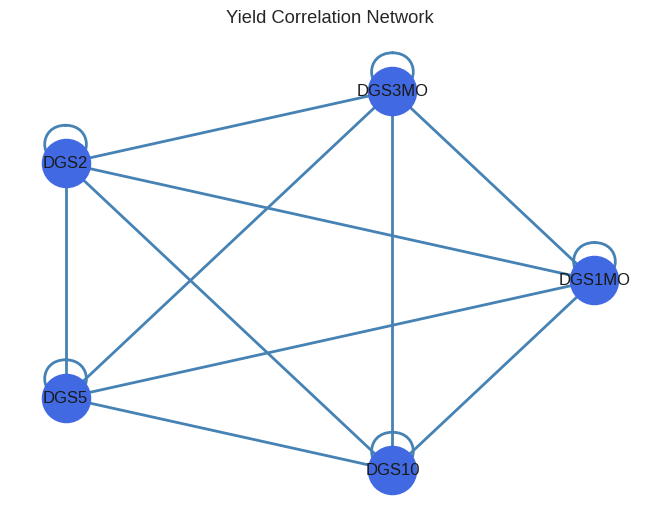

In [ ]:
import networkx as nx

corr = yield_changes.corr()
G = nx.from_pandas_adjacency(corr)
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_color='royalblue', edge_color='steelblue', width=2, node_size=1200)
plt.title("Yield Correlation Network")
plt.show()


The resulting yield correlation network reveals that short, medium, and long term maturities are interconnected through strong correlations, illustrating the smooth propagation of market shocks across the term structure. This visual highlights that yield changes are not isolated but part of a tightly coupled system.By converting statistical relationships into a network graph, we gain a more intuitive understanding of how interdependent movements shape yield dynamics in real markets.

###Conclusion

This project demonstrates how correlation structure and principal component analysis (PCA) reveal the underlying drivers of yield movements in financial markets. By comparing uncorrelated simulated data with real government yield data, we observe a clear contrast, while the simulated data distributes variance fairly evenly across components, the real yield curve is dominated by the first principal component, which alone explains more than 80% of total variance.

Conclusion

This project illustrates how correlation structures and Principal Component Analysis (PCA) can be exploited to uncover the latent factors driving yield curve dynamics.

By comparing uncorrelated simulated data with real government yield data, we observe a clear contrast, while the simulated data distributes variance fairly evenly across components, the real yield curve is dominated by the first principal component, which alone explains more than 80% of total variance. Actual yield curves are heavily dominated by a single factor the level shift which captures the collective movement of interest rates across maturities.

This finding underscores the stability and coherence of market forces influencing the term structure. The PCA framework, therefore, not only simplifies the high dimensional yield data into interpretable factors (level, slope, and curvature) but also provides a foundation for risk management, stress testing, and fixed income portfolio construction.

As a next step, we might ask ourselves. How can we enhance traditional PCA models to capture nonlinear dependencies, regime shifts, or structural breaks in yield correlations, perhaps by integrating machine learning or dynamic factor models to improve predictive accuracy and market risk insight?


**References**

* Cochrane, John H. Asset Pricing. Princeton University Press, 2005.

* Diebold, Francis X., and Canlin Li. “Forecasting the Term Structure of Government Bond Yields.” Journal of Econometrics, vol. 130, no. 2, 2006, pp. 337–364.

* Fabozzi, Frank J. Fixed Income Analysis. 4th ed., Wiley, 2015.

* Jolliffe, Ian T., and Jorge Cadima. “Principal Component Analysis: A Review and Recent Developments.” Philosophical Transactions of the Royal Society A, vol. 374, no. 2065, 2016, pp. 1–16.

* Lee, Raymond S. T. Quantum Finance: Intelligent Forecast and Trading Systems. Springer, 2019.

* Litterman, Robert, and Jose Scheinkman. “Common Factors Affecting Bond Returns.” The Journal of Fixed Income, vol. 1, no. 1, 1991, pp. 54–61.

* Shlens, Jonathon. “A Tutorial on Principal Component Analysis.” arXiv preprint arXiv:1404.1100, 2014.